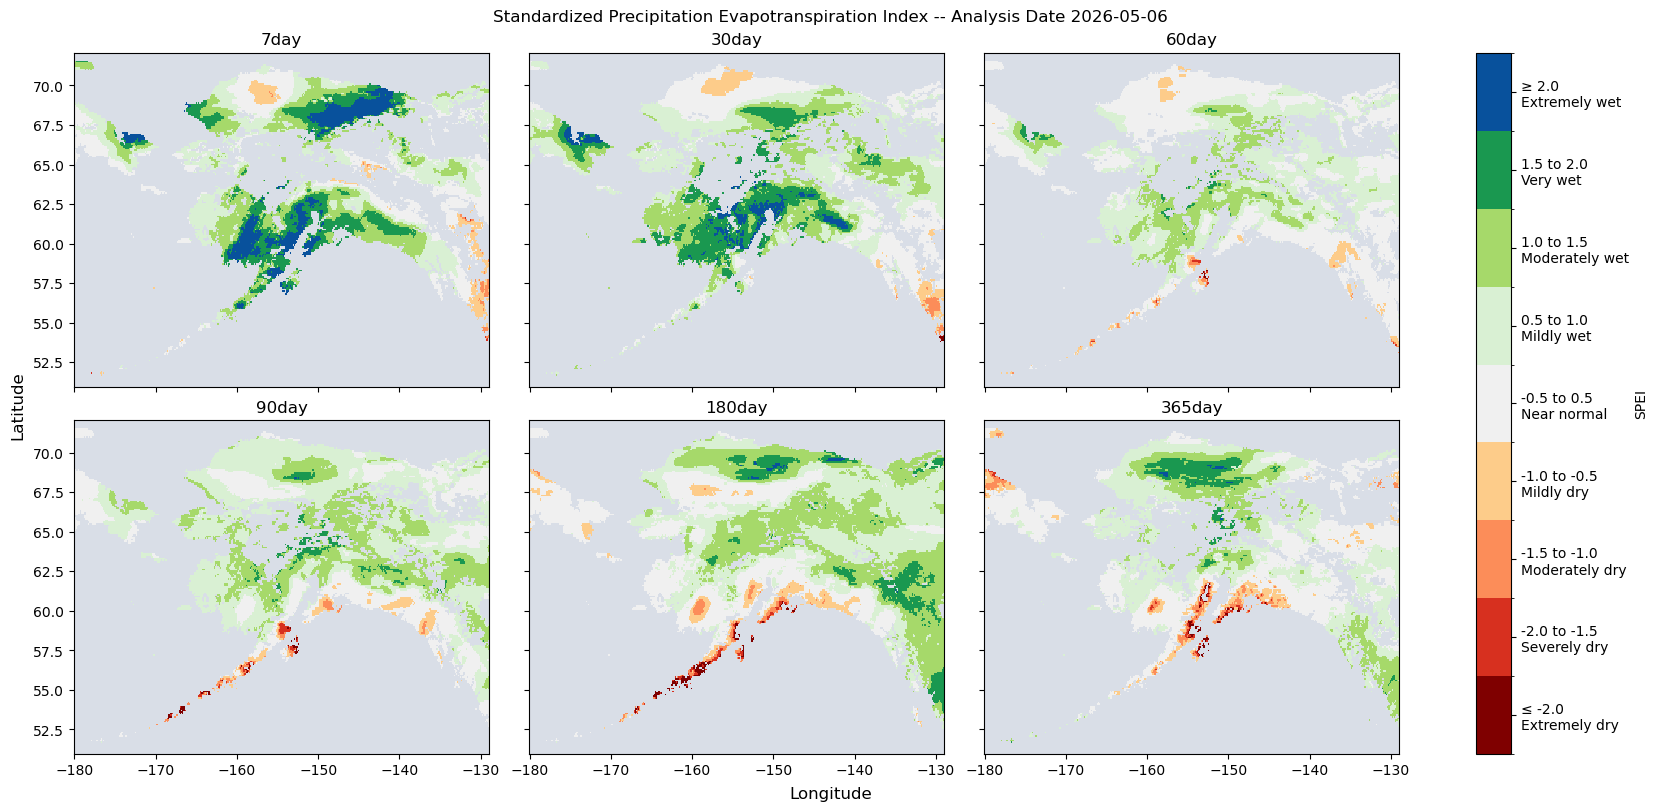

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import BoundaryNorm, ListedColormap

data_dir = Path("snap/drought_outputs")

all_files = [
    Path("snap/drought_outputs/drought_indices_1day.nc"),
    Path("snap/drought_outputs/drought_indices_7day.nc"),
    Path("snap/drought_outputs/drought_indices_30day.nc"),
    Path("snap/drought_outputs/drought_indices_60day.nc"),
    Path("snap/drought_outputs/drought_indices_90day.nc"),
    Path("snap/drought_outputs/drought_indices_180day.nc"),
    Path("snap/drought_outputs/drought_indices_365day.nc"),
]

variable_key = "spei"
long_name = "Standardized Precipitation Evapotranspiration Index"
analysis_date = "2026-05-06"

# Discrete SPEI categories.
#
# SPEI is unitless and behaves like a standardized anomaly:
#   negative = drier-than-normal water-balance conditions
#   positive = wetter-than-normal water-balance conditions
#
# Most SPEI values should usually fall between about -3 and +3.
# Bounds extend to +/-4 so extreme values are clipped into the end categories.
bounds = [
    -4.0,
    -2.0,
    -1.5,
    -1.0,
    -0.5,
    0.5,
    1.0,
    1.5,
    2.0,
    4.0,
]

colors = [
    "#7f0000",  # <= -2.0: extremely dry
    "#d7301f",  # -2.0 to -1.5: severely dry
    "#fc8d59",  # -1.5 to -1.0: moderately dry
    "#fdcc8a",  # -1.0 to -0.5: mildly dry
    "#f0f0f0",  # -0.5 to 0.5: near normal
    "#d9f0d3",  # 0.5 to 1.0: mildly wet
    "#a6d96a",  # 1.0 to 1.5: moderately wet
    "#1a9850",  # 1.5 to 2.0: very wet
    "#08519c",  # >= 2.0: extremely wet
]

cmap = ListedColormap(colors)
cmap.set_bad("#d9dee7")  # ocean / masked cells

norm = BoundaryNorm(bounds, cmap.N, clip=True)

cbar_labels = [
    "≤ -2.0\nExtremely dry",
    "-2.0 to -1.5\nSeverely dry",
    "-1.5 to -1.0\nModerately dry",
    "-1.0 to -0.5\nMildly dry",
    "-0.5 to 0.5\nNear normal",
    "0.5 to 1.0\nMildly wet",
    "1.0 to 1.5\nModerately wet",
    "1.5 to 2.0\nVery wet",
    "≥ 2.0\nExtremely wet",
]

# Bin-center tick positions for categorical colorbar.
cbar_ticks = [
    -3.0,
    -1.75,
    -1.25,
    -0.75,
    0.0,
    0.75,
    1.25,
    1.75,
    3.0,
]

short_window_files = [all_files[0]]
long_window_files = all_files[1::]


def open_nc(path: str | Path) -> xr.Dataset:
    """Open a NetCDF file with decoding enabled."""
    return xr.open_dataset(path)


def plot_variable_across_files(
    paths: list[str | Path],
    figsize_per_panel: tuple[float, float] = (5.5, 4.0),
    save_path: str | Path | None = None,
) -> plt.Figure:
    """Compare SPEI across multiple NetCDF files."""

    ncols = 3
    nrows = 2

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    fig.patch.set_facecolor("white")

    opened: list[tuple[Path, xr.Dataset]] = []

    for path in paths:
        p = Path(path)
        ds = open_nc(p)
        opened.append((p, ds))

    mesh = None

    for ax, (path, ds) in zip(axes.flat, opened, strict=False):
        # Mask ocean using smd, assuming smd is NaN over ocean.
        da = ds[variable_key].where(ds["smd"].notnull())

        lon = ds["longitude"].values
        lat = ds["latitude"].values

        mesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            shading="auto",
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(Path(path).stem.split("_")[-1])
        ax.label_outer()
        ax.set_facecolor("#d9dee7")

    if mesh is None:
        raise ValueError("No input files were provided.")

    fig.supxlabel("Longitude")
    fig.supylabel("Latitude")

    cbar = fig.colorbar(
        mesh,
        ax=axes.ravel().tolist(),
        boundaries=bounds,
        ticks=cbar_ticks,
        spacing="uniform",
    )

    cbar.set_ticklabels(cbar_labels)
    cbar.set_label("SPEI")

    fig.suptitle(
        f"{long_name} -- Analysis Date {analysis_date}",
        fontsize=12,
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")


plot_variable_across_files(long_window_files, save_path="spei.png")